# ML Final Project
Trevor Xu

# Predicting Daily Respiratory Hospital Admissions from Air Pollution: A Comparison of Linear Models, SVR, and Neural Networks

## Project Overview

This project investigates whether daily air pollution and weather conditions can be used to predict respiratory hospital admissions. Using a real-world dataset that combines air quality indicators (such as PM2.5, PM10, NO₂, O₃), meteorological variables (temperature, humidity, wind speed), mobility and policy indicators with daily counts of respiratory admissions, we formulate a supervised regression task with a single target: the number of respiratory admissions per day. The data are sorted chronologically and split into training, validation, and test sets to respect the time structure and avoid information leakage.

Methodologically, we compare three families of models that reflect key topics from the course: a regularized linear model (Ridge regression), a kernel-based method (Support Vector Regression with an RBF kernel), and a feed-forward neural network implemented in PyTorch. A unified preprocessing pipeline with standardization and one-hot encoding is applied across all models, and hyperparameters are tuned using validation performance. The models are evaluated on the held-out test set using RMSE and R², allowing us to assess both overall predictive accuracy and the ability to capture variability in hospital admissions. Beyond raw performance, we discuss the trade-offs between interpretability and flexibility, and what the results imply about how much of the burden on respiratory health can be explained by the observed environmental and behavioral factors.

# Dataset Overview

In [ ]:
import pandas as pd

df = pd.read_csv("air_quality_health_dataset.csv", parse_dates=["date"])

print(df.shape)
print(df.columns)
print(df.head())


(3000, 26)
Index(['date', 'region', 'AQI', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3',
       'temperature', 'humidity', 'wind_speed', 'precipitation',
       'hospital_visits', 'emergency_visits', 'mobility_index',
       'school_closures', 'public_transport_usage', 'mask_usage_rate',
       'lockdown_status', 'industrial_activity', 'vehicle_count',
       'construction_activity', 'respiratory_admissions', 'population_density',
       'green_cover_percentage'],
      dtype='object')
        date   region         AQI      PM2.5       PM10        NO2        SO2  \
0 2020-01-01     East  109.934283  31.382887  57.718373  47.654022  25.874070   
1 2020-01-02  Central   97.234714  47.094225  67.381383  50.734127  10.605095   
2 2020-01-03     East  112.953771  53.795917  61.158796  44.986899  18.361025   
3 2020-01-04     West  130.460597  88.315315  69.040084  20.575023  19.791700   
4 2020-01-05    South   95.316933  68.348297  75.716994  38.445776  20.079543   

         CO         O3  t

There are 3000 samples and 26 features in this dataset, we will use **respiratory_admissions** as our y_predict, and the rest of features are X, but we have to think about the relationship between those features, cause some features do not contribute a lot to predicting, and some of them are the same meaning with y.

In [ ]:
print("Shape:", df.shape)        # (n_rows, n_cols)
print("\nColumns:", df.columns.tolist())

print("\nInfo:")
print(df.info())

print("\nTarget describe (respiratory_admissions):")
print(df["respiratory_admissions"].describe())

print("\nNumeric features describe:")
num_cols = df.select_dtypes(include="number").columns
print(df[num_cols].describe().T)

print("\nMissing rate by column:")
print(df.isna().mean().sort_values(ascending=False))


Shape: (3000, 26)

Columns: ['date', 'region', 'AQI', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3', 'temperature', 'humidity', 'wind_speed', 'precipitation', 'hospital_visits', 'emergency_visits', 'mobility_index', 'school_closures', 'public_transport_usage', 'mask_usage_rate', 'lockdown_status', 'industrial_activity', 'vehicle_count', 'construction_activity', 'respiratory_admissions', 'population_density', 'green_cover_percentage']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   date                    3000 non-null   datetime64[ns]
 1   region                  3000 non-null   object        
 2   AQI                     3000 non-null   float64       
 3   PM2.5                   3000 non-null   float64       
 4   PM10                    3000 non-null   float64       
 5   NO2                     300

Very good, no null values!!

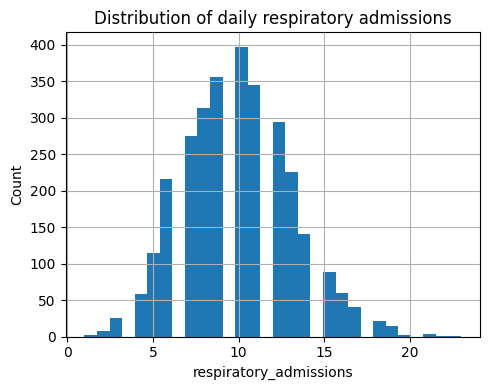

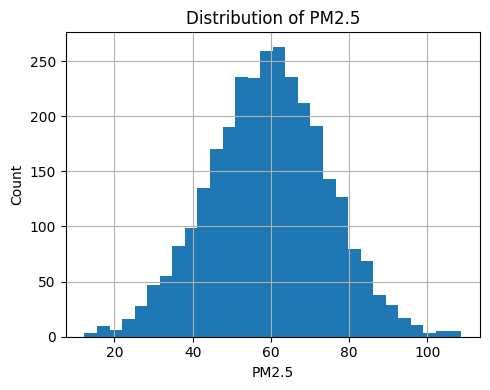

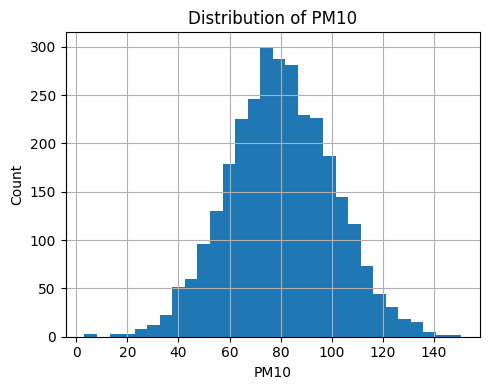

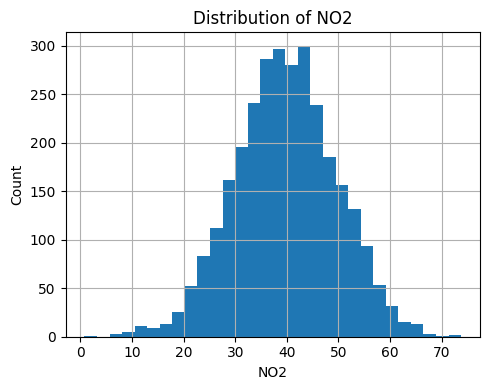

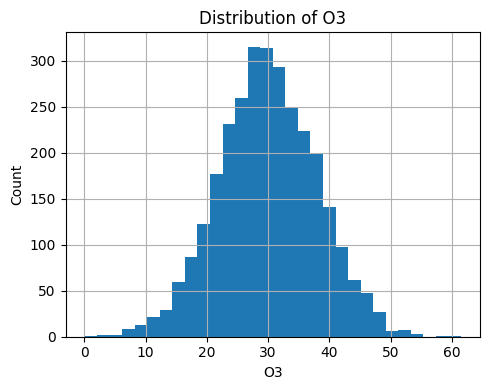

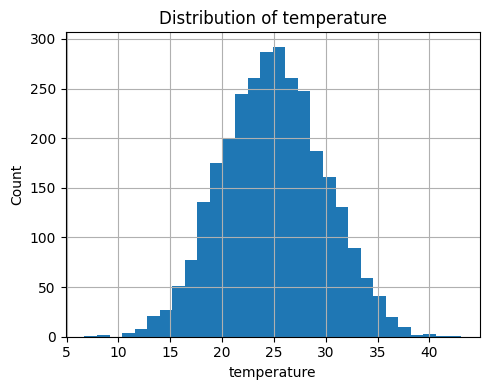

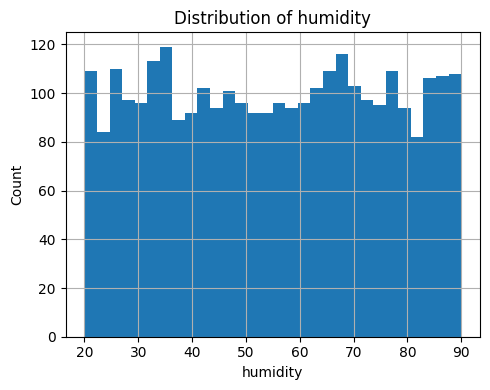

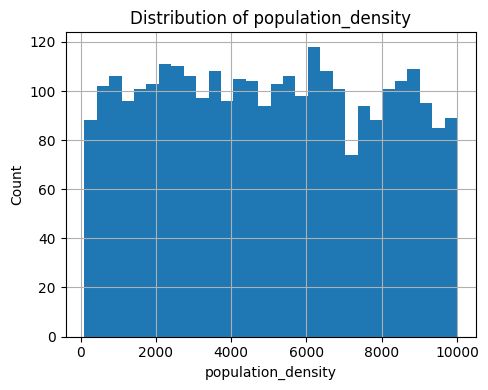

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
df["respiratory_admissions"].hist(bins=30)
plt.xlabel("respiratory_admissions")
plt.ylabel("Count")
plt.title("Distribution of daily respiratory admissions")
plt.tight_layout()
plt.show()

important_features = ["PM2.5", "PM10", "NO2", "O3",
                      "temperature", "humidity", "population_density"]

for col in important_features:
    if col in df.columns:
        plt.figure(figsize=(5,4))
        df[col].hist(bins=30)
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.title(f"Distribution of {col}")
        plt.tight_layout()
        plt.show()


Most of features are symmetric distribution, the distribution is more stable, the data may perform better in linear model than the non-linear one.

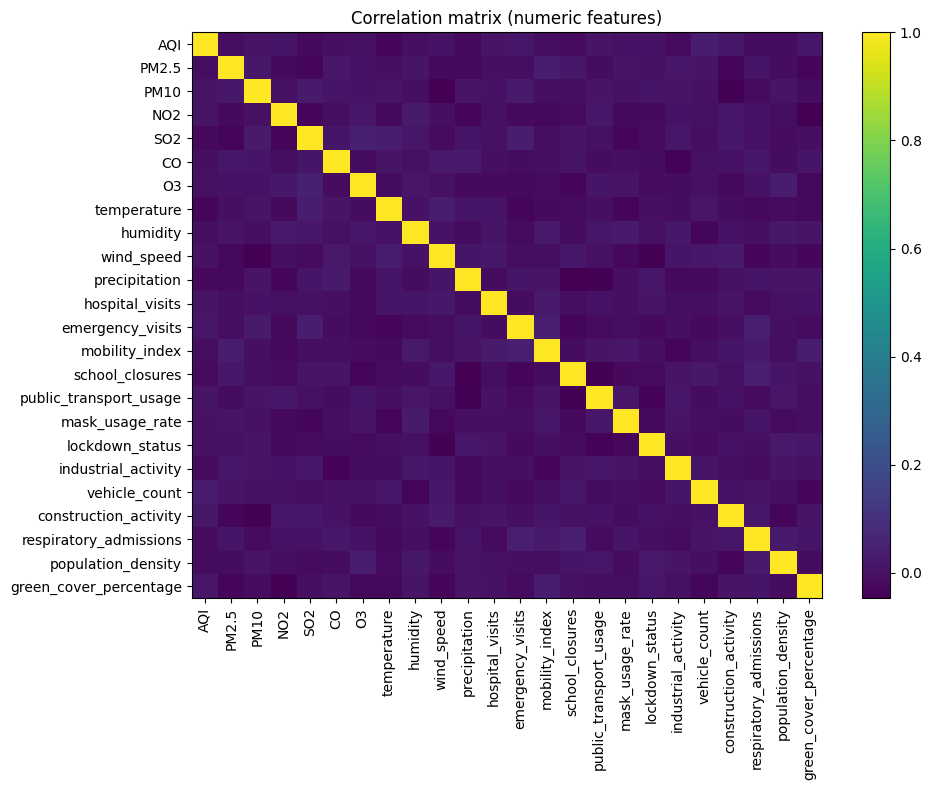


Correlation with respiratory_admissions:
respiratory_admissions    1.000000
emergency_visits          0.042702
school_closures           0.042306
mobility_index            0.027739
population_density        0.027679
CO                        0.022553
construction_activity     0.016354
green_cover_percentage    0.013916
PM2.5                     0.013296
precipitation             0.012906
mask_usage_rate           0.012882
vehicle_count             0.007145
SO2                       0.003700
NO2                       0.003590
O3                        0.002623
humidity                 -0.003430
lockdown_status          -0.004197
AQI                      -0.010069
industrial_activity      -0.014643
PM10                     -0.016095
public_transport_usage   -0.016924
hospital_visits          -0.018034
temperature              -0.023425
wind_speed               -0.032580
Name: respiratory_admissions, dtype: float64


In [ ]:
import numpy as np

num_cols = df.select_dtypes(include="number").columns
corr = df[num_cols].corr()

plt.figure(figsize=(10,8))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(ticks=np.arange(len(num_cols)), labels=num_cols, rotation=90)
plt.yticks(ticks=np.arange(len(num_cols)), labels=num_cols)
plt.title("Correlation matrix (numeric features)")
plt.tight_layout()
plt.show()

target = "respiratory_admissions"
corr_with_y = corr[target].sort_values(ascending=False)
print("\nCorrelation with respiratory_admissions:")
print(corr_with_y)


All predictors have very weak marginal linear correlations with daily respiratory admissions (|r| < 0.05), suggesting that no single feature is strongly informative on its own.

# Data Split

In [ ]:
target = "respiratory_admissions"
y = df[target]

In [ ]:
df = df.sort_values("date").reset_index(drop=True)

df["month"] = df["date"].dt.month
df["dayofweek"] = df["date"].dt.dayofweek  # Monday=0

exclude_cols = ["date", target, "hospital_visits", "emergency_visits"]
feature_cols = [c for c in df.columns if c not in exclude_cols]

print("Features:", feature_cols)

Features: ['region', 'AQI', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3', 'temperature', 'humidity', 'wind_speed', 'precipitation', 'mobility_index', 'school_closures', 'public_transport_usage', 'mask_usage_rate', 'lockdown_status', 'industrial_activity', 'vehicle_count', 'construction_activity', 'population_density', 'green_cover_percentage', 'month', 'dayofweek']


In this part, we are building the X, y. We sort the data with the date, cause we will split the data depend on the date, also the **hospital_visits and emergency_visits** are already be included in the y, so we do not use it as features.

In [ ]:
import numpy as np

X = df[feature_cols]
y = df[target]

n = len(df)
n_train = int(n * 0.7)
n_val = int(n * 0.85)

X_train = X.iloc[:n_train]
y_train = y.iloc[:n_train]

X_val   = X.iloc[n_train:n_val]
y_val   = y.iloc[n_train:n_val]

X_test  = X.iloc[n_val:]
y_test  = y.iloc[n_val:]

len(X_train), len(X_val), len(X_test)

(2100, 450, 450)

# Preprocessing

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

categorical_features = ["region"]
numeric_features = [c for c in feature_cols if c not in categorical_features]

In [ ]:
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95))
])

“We apply PCA to the standardized numeric features, retaining 95% of the variance, in order to reduce dimensionality and decorrelate predictors before fitting Ridge and SVR models.”

In [ ]:
preprocessor_pca = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", OneHotEncoder(drop="first"), categorical_features),
    ]
)

In this step, we use the standard scaler and PCA to do the data preprocessing for the numeric features, for the region as an categorical feature, we use one-hot coding to deal with this. At the end, we use a pipeline to put them together, and use it when we train the model.

But, even though we used the PCA, the result may still not be good. Because all features have a weak relationship with y.

# Ridge Regression

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
ridge_results = []

for alpha in alphas:
    ridge = Pipeline(steps=[
        ("preprocess", preprocessor_pca),
        ("model", Ridge(alpha=alpha, random_state=0))
    ])
    ridge.fit(X_train, y_train)

    y_val_pred = ridge.predict(X_val)
    mse_val = mean_squared_error(y_val, y_val_pred)
    rmse_val = mse_val ** 0.5
    r2_val = r2_score(y_val, y_val_pred)

    ridge_results.append((alpha, rmse_val, r2_val))

print("Ridge validation results:")
for alpha, rmse, r2 in ridge_results:
    print(f"  alpha={alpha:6}: Val RMSE={rmse:.3f}, R2={r2:.3f}")

best_alpha, _, _ = max(ridge_results, key=lambda x: x[2])
print("\nBest alpha (by Val R2):", best_alpha)

Ridge validation results:
  alpha=  0.01: Val RMSE=3.092, R2=-0.038
  alpha=   0.1: Val RMSE=3.092, R2=-0.038
  alpha=   1.0: Val RMSE=3.092, R2=-0.038
  alpha=  10.0: Val RMSE=3.091, R2=-0.037
  alpha= 100.0: Val RMSE=3.086, R2=-0.034

Best alpha (by Val R2): 100.0


This part is about hyperparameter search: We are trying different alphas (L2 regularization strengths) in a small list [0.01, 0.1, 1, 10, 100]. Finally, select the alpha from ridge_results that yields the maximum R² on the validation set as the regularization strength we will use.

In [ ]:
import pandas as pd

X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

best_ridge = Pipeline(steps=[
    ("preprocess", preprocessor_pca),
    ("model", Ridge(alpha=best_alpha, random_state=0))
])
best_ridge.fit(X_train_full, y_train_full)

y_test_pred_ridge = best_ridge.predict(X_test)
mse_test_ridge = mean_squared_error(y_test, y_test_pred_ridge)
rmse_test_ridge = mse_test_ridge ** 0.5
r2_test_ridge = r2_score(y_test, y_test_pred_ridge)

print(f"Ridge on TEST: RMSE={rmse_test_ridge:.3f}, R2={r2_test_ridge:.3f}")


Ridge on TEST: RMSE=3.188, R2=-0.012


After selecting the optimal alpha, we combine train and val (into a larger training set train_full) and retrain a "final version" of the Ridge model. After training, we make predictions using X_test to obtain y_test_pred_ridge and calculate RMSE and R² on the test set.

As a linear baseline, Ridge regression achieved an RMSE of 3.19 and an R² of –0.01 on the test set. An R² slightly below zero indicates that the model performs marginally worse than a naive baseline that always predicts the mean number of admissions. This result is consistent with the very weak marginal correlations observed between the predictors and daily respiratory admissions, suggesting that the linear signal in the available features is extremely limited.

# SVM

In [ ]:
from sklearn.svm import SVR

C_values = [1.0, 10.0, 100.0]
gamma_values = ["scale", 0.1, 0.01]
epsilon = 0.1

svr_results = []

for C in C_values:
    for gamma in gamma_values:
        svr = Pipeline(steps=[
            ("preprocess", preprocessor_pca),
            ("model", SVR(C=C, gamma=gamma, epsilon=epsilon, kernel="rbf"))
        ])
        svr.fit(X_train, y_train)

        y_val_pred = svr.predict(X_val)
        mse_val = mean_squared_error(y_val, y_val_pred)
        rmse_val = np.sqrt(mse_val)
        r2_val = r2_score(y_val, y_val_pred)

        svr_results.append((C, gamma, rmse_val, r2_val))

print("\nSVR validation results:")
for C, gamma, rmse, r2 in svr_results:
    print(f"  C={C:5}, gamma={str(gamma):>6} -> Val RMSE={rmse:.3f}, R2={r2:.3f}")

best_C, best_gamma, _, _ = max(svr_results, key=lambda x: x[3])
print("\nBest SVR params (by Val R2): C=", best_C, ", gamma=", best_gamma)


SVR validation results:
  C=  1.0, gamma= scale -> Val RMSE=3.112, R2=-0.051
  C=  1.0, gamma=   0.1 -> Val RMSE=3.088, R2=-0.035
  C=  1.0, gamma=  0.01 -> Val RMSE=3.071, R2=-0.023
  C= 10.0, gamma= scale -> Val RMSE=3.359, R2=-0.224
  C= 10.0, gamma=   0.1 -> Val RMSE=3.218, R2=-0.124
  C= 10.0, gamma=  0.01 -> Val RMSE=3.175, R2=-0.094
  C=100.0, gamma= scale -> Val RMSE=3.650, R2=-0.446
  C=100.0, gamma=   0.1 -> Val RMSE=3.240, R2=-0.139
  C=100.0, gamma=  0.01 -> Val RMSE=3.422, R2=-0.271

Best SVR params (by Val R2): C= 1.0 , gamma= 0.01


In [ ]:
best_svr = Pipeline(steps=[
    ("preprocess", preprocessor_pca),
    ("model", SVR(C=best_C, gamma=best_gamma, epsilon=epsilon, kernel="rbf"))
])
best_svr.fit(X_train_full, y_train_full)

y_test_pred_svr = best_svr.predict(X_test)
mse_test_svr = mean_squared_error(y_test, y_test_pred_svr)
rmse_test_svr = np.sqrt(mse_test_svr)
r2_test_svr = r2_score(y_test, y_test_pred_svr)

print(f"SVR on TEST:   RMSE={rmse_test_svr:.3f}, R2={r2_test_svr:.3f}")

SVR on TEST:   RMSE=3.208, R2=-0.025


The fact that both a linear model (Ridge) and a flexible nonlinear model (SVR with RBF kernel) fail to improve over the mean baseline is consistent with the extremely weak marginal correlations observed between the predictors and respiratory admissions. In this dataset, adding nonlinear capacity does not reveal a strong underlying signal; instead, it likely leads the model to fit noise in the training data without improving generalization.

# PyTorch MLP

In [ ]:
preprocessor_pca.fit(X_train_full)

X_train_full_proc = preprocessor_pca.transform(X_train_full)
X_test_proc = preprocessor_pca.transform(X_test)

In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader

X_train_t = torch.tensor(X_train_full_proc, dtype=torch.float32)
y_train_t = torch.tensor(y_train_full.values, dtype=torch.float32).view(-1, 1)

X_test_t = torch.tensor(X_test_proc, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

train_ds = TensorDataset(X_train_t, y_train_t)
test_ds  = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=256, shuffle=False)

input_dim = X_train_t.shape[1]
print("Input dim for MLP:", input_dim)

Input dim for MLP: 26


In [ ]:
import torch.nn as nn

class MLPRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 26),
            nn.ReLU(),
            nn.Linear(26, 13),
            nn.ReLU(),
            nn.Linear(13, 1)
        )
    def forward(self, x):
        return self.net(x)

model = MLPRegressor(input_dim)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def evaluate_loader(model, loader):
    model.eval()
    preds = []
    trues = []
    with torch.no_grad():
        for xb, yb in loader:
            out = model(xb)
            preds.append(out.cpu().numpy())
            trues.append(yb.cpu().numpy())
    preds = np.vstack(preds).ravel()
    trues = np.vstack(trues).ravel()
    mse = mean_squared_error(trues, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(trues, preds)
    return rmse, r2


In [ ]:
n_epochs = 100

for epoch in range(1, n_epochs + 1):
    model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

    if epoch % 10 == 0:
        train_rmse, train_r2 = evaluate_loader(model, train_loader)
        test_rmse, test_r2 = evaluate_loader(model, test_loader)
        print(f"Epoch {epoch:3d}: Train RMSE={train_rmse:.3f}, R2={train_r2:.3f} | "
              f"Val RMSE={test_rmse:.3f}, R2={test_r2:.3f}")


Epoch  10: Train RMSE=3.175, R2=-0.011 | Val RMSE=3.362, R2=-0.126
Epoch  20: Train RMSE=3.100, R2=0.036 | Val RMSE=3.334, R2=-0.107
Epoch  30: Train RMSE=3.044, R2=0.071 | Val RMSE=3.325, R2=-0.101
Epoch  40: Train RMSE=2.993, R2=0.102 | Val RMSE=3.317, R2=-0.096
Epoch  50: Train RMSE=2.945, R2=0.130 | Val RMSE=3.336, R2=-0.108
Epoch  60: Train RMSE=2.909, R2=0.152 | Val RMSE=3.352, R2=-0.119
Epoch  70: Train RMSE=2.876, R2=0.170 | Val RMSE=3.358, R2=-0.123
Epoch  80: Train RMSE=2.837, R2=0.193 | Val RMSE=3.388, R2=-0.143
Epoch  90: Train RMSE=2.806, R2=0.211 | Val RMSE=3.420, R2=-0.165
Epoch 100: Train RMSE=2.774, R2=0.228 | Val RMSE=3.443, R2=-0.180


In [ ]:
test_rmse_mlp, test_r2_mlp = evaluate_loader(model, test_loader)
print(f"MLP on TEST:   RMSE={test_rmse_mlp:.3f}, R2={test_r2_mlp:.3f}")


MLP on TEST:   RMSE=3.443, R2=-0.180


In [ ]:
df[target].describe()

,respiratory_admissions
count,3000.000000
mean,9.923333
std,3.161031
min,1.000000
25%,8.000000
50%,10.000000
75%,12.000000
max,23.000000


The target variable has a mean of 9.92 admissions/day with a standard deviation of 3.16 (IQR: 8–12). The MLP achieved a test RMSE of 3.44, which is slightly larger than the target’s standard deviation (RMSE/std ≈ 1.09). This indicates that the model’s typical prediction error is on the same order as, or larger than, the natural day-to-day variability in admissions. Consistently, the test R² is negative (−0.18), meaning the MLP performs worse than a simple mean baseline. This aligns with the exploratory analysis showing extremely weak marginal correlations between predictors and admissions, suggesting limited predictive signal in the available features and a high risk of overfitting for flexible models.

# Conclusion



In this project, we set up a time-aware regression task to predict daily respiratory hospital admissions using air pollution, weather, mobility/policy, and regional indicators. The target variable has a mean of 9.92 admissions/day with a standard deviation of 3.16 (IQR 8–12, range 1–23), meaning day-to-day variation is relatively modest. Exploratory analysis also showed that all predictors have extremely weak marginal linear relationships with admissions (|r| < 0.05), suggesting limited predictive signal in the available features.

Across models, test performance was consistently near (or worse than) a mean baseline: Ridge achieved RMSE = 3.188, R² = −0.012, SVR (RBF) achieved RMSE = 3.208, R² = −0.025, and the MLP achieved RMSE = 3.443, R² = −0.180. The negative R² values indicate that none of the models generalized better than simply predicting the training mean, and the RMSE values (≈3.2–3.4) are on the same scale as the target’s natural variability (std ≈ 3.16). Overall, the results imply that—given this dataset and feature set—daily respiratory admissions are largely driven by unobserved factors (e.g., seasonal viruses, demographics, healthcare access, reporting artifacts) or relationships not captured by the recorded variables. Future work would likely require richer health and contextual covariates, alternative target definitions (e.g., weekly aggregation to reduce noise), and stronger time-series features (lags/rolling averages) to achieve meaningful predictive performance.

# Takeaway

1. PCA number of n

In this dataset, using PCA(n_components=0.95) ends up keeping almost all numeric features because there is no strong redundancy structure among them. In a “nice” compressible case, several features are highly correlated (for example, PM2.5, PM10, and AQI all moving together), so a small number of principal components can already explain most of the total variance, and the remaining components mainly capture noise. Here, however, the numeric predictors appear to contribute variance in a more balanced and independent way: no small subset of directions dominates, and there is no clear low-dimensional structure that PCA can exploit. But by testing, when n equal to the 3/10, the result still almost keep same, so in this very weak relationship dataset, no matter use which N, the PCA do not effect a lot.

2. Preview data to decide which model to use.

Early exploratory analysis played a crucial role in setting realistic expectations for model performance. By examining the distribution of the target variable and computing marginal correlations, we observed that all predictors have extremely weak linear relationships with daily respiratory admissions (|r| < 0.05). This preview already suggested that the available features contain limited predictive signal.

Given this context, it is not surprising that more flexible models such as SVR and MLP did not outperform simpler models like Ridge regression. In fact, the neural network performed worse due to overfitting in a low-signal setting. This highlights an important lesson: model complexity should be informed by data characteristics. When the signal is weak and noisy, simpler and more stable models often generalize better than highly flexible ones.

3. Data leaking

For this dataset, data leakage would mainly arise if information from the test period were used, even indirectly, during model training. Because the task is to predict daily respiratory admissions over time, any operation that allows the model to access statistics computed using future observations would lead to overly optimistic results that do not reflect real-world generalization. A particularly subtle risk occurs during preprocessing steps such as standardization and PCA: if these transformations are fit on the full dataset before splitting, the resulting means, variances, or principal component directions would be influenced by the test data, effectively allowing the model to “peek into the future.” To prevent this, the data were first split into training and test sets based on time, and only then were standardization and PCA fit using the training data. The learned transformations were subsequently applied to the test set without refitting. This ensures that the reported test performance reflects genuine out-of-sample behavior rather than information leakage, which is especially important in this dataset where predictive signal is weak and even small apparent improvements could otherwise be misleading.